# **1. Data Analysis**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

df_raw = pd.read_csv('Raw_dataset.csv')


## Choosing Numeric Attribute

In [64]:
numeric_cols=["age","fnlwgt","educational-num","capital-gain","capital-loss","hours-per-week"]
numeric_cols

['age',
 'fnlwgt',
 'educational-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

## Five number&&Statistical Summary

In [65]:
five_num = df_raw[numeric_cols].describe().loc[['min', '25%', '50%', '75%', 'max']]
display(five_num)
sammary=df_raw[numeric_cols].describe()
display(sammary)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
min,17.0,12285.0,1.0,0.0,0.0,1.0
25%,28.0,117550.5,9.0,0.0,0.0,40.0
50%,37.0,178144.5,10.0,0.0,0.0,40.0
75%,48.0,237642.0,12.0,0.0,0.0,45.0
max,90.0,1490400.0,16.0,99999.0,4356.0,99.0


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


**Age:** Min 17, Q1 28, median 37, Q3 48, max 90. Most individuals are between 28 and 48 years old, and the maximum is far above Q3, so values above 78 may be considered potential outliers.

**fnlwgt:** Min 12,285, Q1 117,550, median 178,145, Q3 237,642, max 1,490,400. The maximum is much larger than Q3, which indicates high variability and possible outliers.

**Education-num:** Min 1, Q1 9, median 10, Q3 12, max 16. Most individuals have education levels between 9 and 12, and the low values (below 4.5) may be potential outliers.

**Hours-per-week:** Min 1, Q1 40, median 40, Q3 45, max 99. Most individuals work around 40 hours per week, with values at both extremes indicating potential outliers.

**Capital-gain and Capital-loss:** Min, Q1, median and Q3 are all 0, while the maximums are 99,999 and 4,356. Most values are 0, and a small number of very large values suggest the presence of outliers and a highly skewed distribution.

The five-number summary shows the center and spread of each numerical attribute, helping identify skewness and potential outliers.

## Histogram

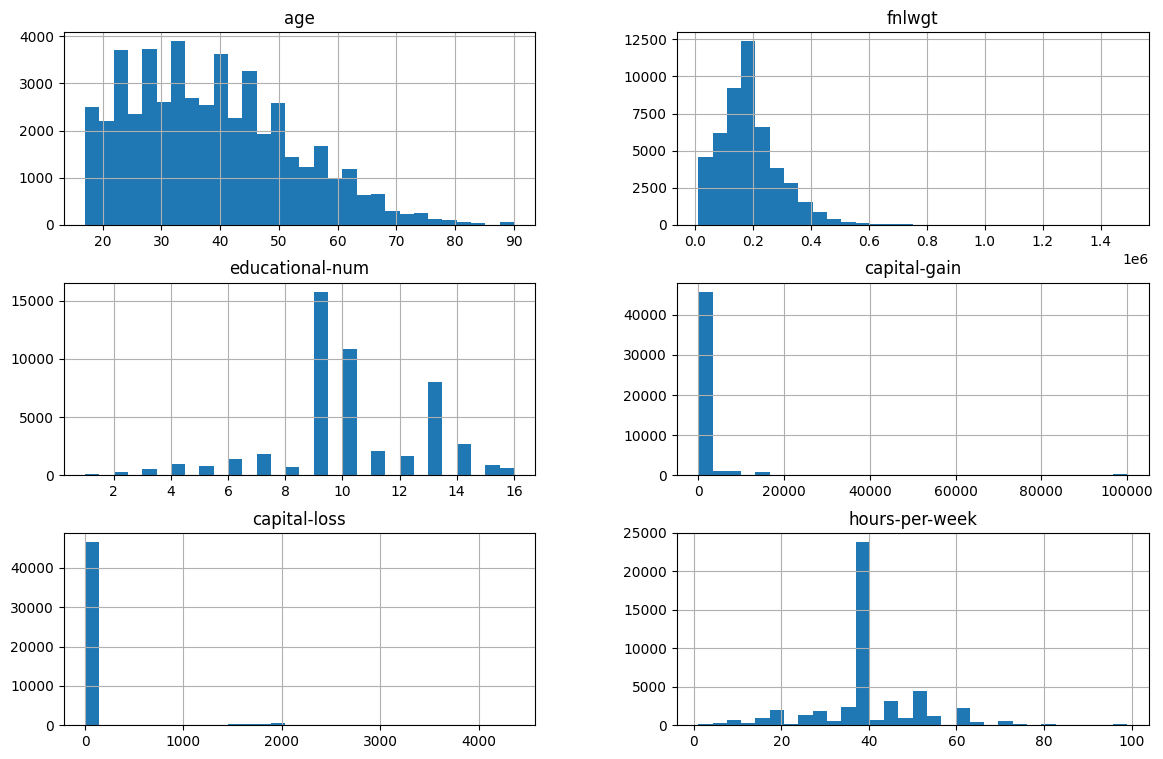

In [66]:
df_raw[numeric_cols].hist(bins=30, figsize=(14, 9))
plt.show()

The histograms show that capital-gain and capital-loss are very right skewed. Almost all the values are in the first bar at 0, and only a few small bars appear far to the right (around 100000 for capital-gain and between 1500 and 2500 for capital-loss). fnlwgt is also right skewed, because most values are between 0 and 0.4 million and there is a long tail that goes up to about 1.5 million. Age is a little right skewed, most people are between 20 and 50 and the number of people gets smaller after 60. educational-num has high bars at 9, 10 and 13, and hours-per-week has a very big peak at 40 hours with few values near 99. Because capital-gain, capital-loss and fnlwgt have long right tails and extreme values, we will apply log transformation on them.

##Boxplots

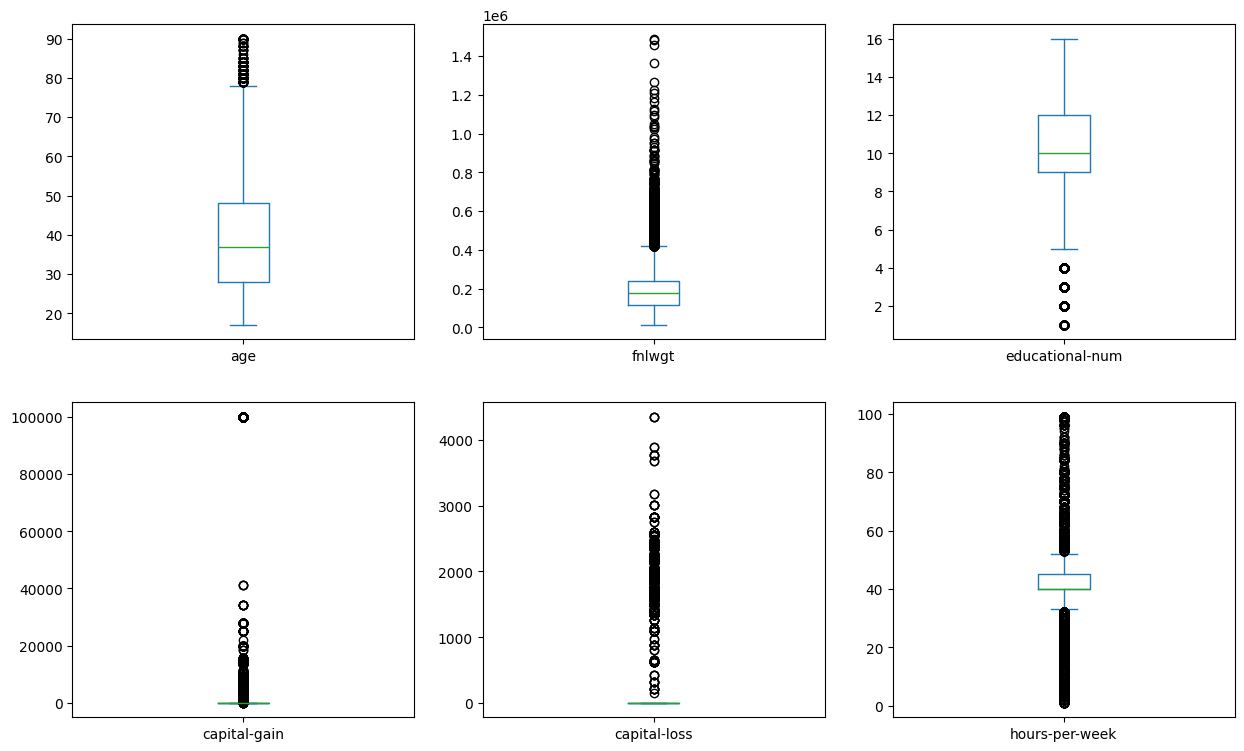

In [67]:
df_raw[numeric_cols].plot(kind='box', subplots=True, layout=(2, 3), figsize=(15, 9))
plt.show()

The boxplots show outliers in all numeric attributes. Age has a few outliers above 78, fnlwgt has many high outliers up to about 1.5 million, and educational-num has low outliers between 1 and 4. For capital-gain and capital-loss the box is flat at 0, so every value above 0 is an outlier, with capital-gain reaching about 100000. hours-per-week has a narrow box between 40 and 45, so values below about 32 and above about 52 are outliers. These are real values, so we kept them and reduced their effect with log transformation and normalization.

## Outlier Analysis

In [68]:
Q1 = df_raw[numeric_cols].quantile(0.25)
Q3 = df_raw[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = ((df_raw[numeric_cols] < lower) | (df_raw[numeric_cols] > upper)).sum()
pd.DataFrame({'lower': lower, 'upper': upper, 'outliers': outliers})

,lower,upper,outliers
age,-2.00,78.00,216
fnlwgt,-62586.75,417779.25,1453
educational-num,4.50,16.50,1794
capital-gain,0.00,0.00,4035
capital-loss,0.00,0.00,2282
hours-per-week,32.50,52.50,13496


The boxplots and the IQR method show many outliers in capital-gain, capital-loss and hours-per-week. For capital-gain and capital-loss the IQR is 0, so any value that is not 0 is counted as an outlier. For hours-per-week the IQR is small (40 to 45), so people who work part time or long hours are counted as outliers. These values are real and make sense (for example working 60 hours or having capital gain), so we did not remove them. We will reduce their effect with log transformation and normalization instead.

## Scatter Plot

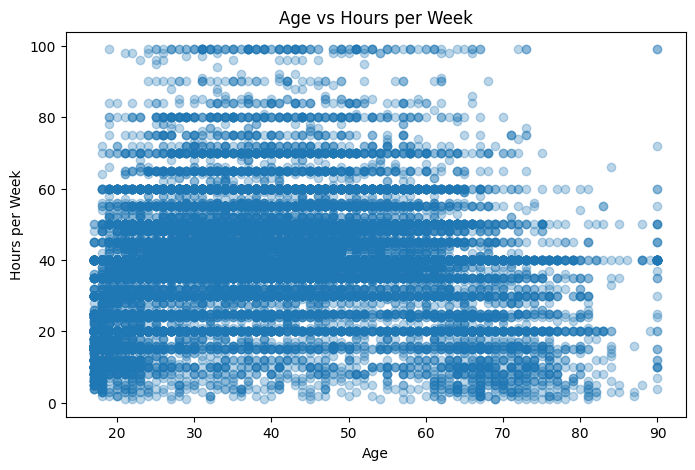

In [69]:
plt.figure(figsize=(8,5))
plt.scatter(df_raw['age'], df_raw['hours-per-week'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.title('Age vs Hours per Week')

plt.show()

There is no strong relationship between age and hours-per-week. Most individuals are between 20–60 years old and work around 35–45 hours per week. Some extreme observations can be seen, such as very old individuals with unusually high working hours. These observations should be examined during preprocessing for possible outliers.

## Bar Plot of Categorical Attribute

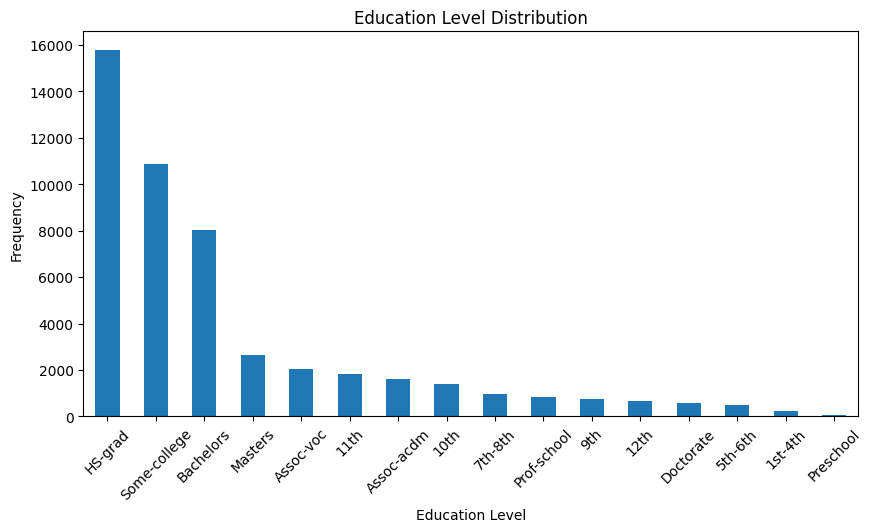

In [70]:
df_raw['education'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.title('Education Level Distribution')
plt.xticks(rotation=45)

plt.show()

The bar plot shows that HS-grad is the most common education level, then Some-college and Bachelors. Levels like Preschool and 1st-4th have very few records, so the categories are not balanced.

## Missing Values Analysis

In [71]:
missing = (df_raw == '?').sum()
missing = missing[missing > 0]
missing_table = pd.DataFrame({'Attribute': missing.index, 'Missing Count': missing.values, 'Missing Percentage': (missing.values / len(df_raw) * 100).round(2)})
missing_table

,Attribute,Missing Count,Missing Percentage
0,workclass,2799,5.73
1,occupation,2809,5.75
2,native-country,857,1.75


There are 3 attributes with missing values: occupation (2809,%5.75), workclass (2799,%5.73) and native-country (857,%1.75). These missing values should be handled appropriately, as they may affect the accuracy and reliability of the analysis results.

## Class Label Plot

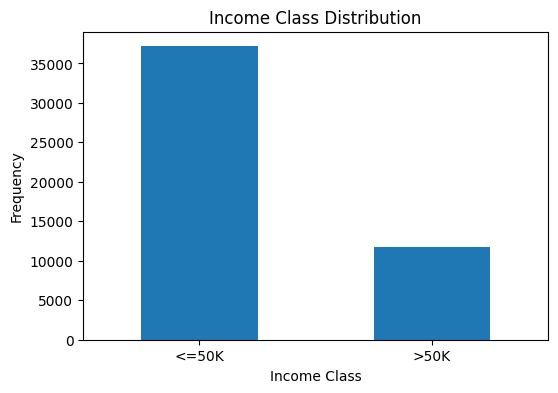

In [72]:
plt.figure(figsize=(6,4))
df_raw['income'].astype(str).str.strip().value_counts().plot(kind='bar')
plt.xlabel('Income Class')
plt.ylabel('Frequency')
plt.title('Income Class Distribution')
plt.xticks(rotation=0)

plt.show()

The income classes are clearly imbalanced. Most individuals belong to the <=50K class, while the >50K class contains considerably fewer observations. This imbalance may cause the model to favor the majority class, so it should be considered during preprocessing and model development.

# **2. Data Preprocessing**

In [74]:
df_preprocessed = df_raw.copy()

## Missing Values Handling

In [75]:
df_preprocessed = df_preprocessed.replace('?', np.nan)
before = df_preprocessed.isna().sum()
before

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [76]:
df_preprocessed = df_preprocessed.replace('?', np.nan)
df_preprocessed = df_preprocessed.dropna(subset=['occupation'])
df_preprocessed['native-country'] = df_preprocessed['native-country'].fillna(df_preprocessed['native-country'].mode()[0])
print(df_preprocessed.shape)
df_preprocessed.isna().sum()

(46033, 15)


,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


Missing values were found in workclass, occupation, and native-country. Rows with missing occupation were removed, while missing native-country values were replaced with the mode. After handling, the dataset had 46,033 rows and no missing values remained.

## Noise Removal

In [77]:
print("Duplicate rows before:", df_preprocessed.duplicated().sum())
df_preprocessed = df_preprocessed.drop_duplicates()
print("Duplicate rows after:", df_preprocessed.duplicated().sum())
print(df_preprocessed.shape)

Duplicate rows before: 48
Duplicate rows after: 0
(45985, 15)


We checked the dataset for duplicate rows because repeated records are noise. They do not add new information and give the same record more weight than the others. We found 48 duplicate rows and removed them using drop_duplicates(). Now the dataset has 0 duplicates and 45985 rows.

## Variable Transformation

In [78]:
cols = ['fnlwgt', 'capital-gain', 'capital-loss']
before = df_preprocessed[cols].skew()
df_preprocessed[cols] = np.log1p(df_preprocessed[cols])
pd.DataFrame({'before': before, 'after': df_preprocessed[cols].skew()}).round(2)

,before,after
fnlwgt,1.44,-0.83
capital-gain,11.68,3.08
capital-loss,4.51,4.27


The histograms showed strong right skewness in fnlwgt, capital-gain and capital-loss, so we applied log transformation using np.log because these columns have 0 values. Skewness of capital-gain went from 11.68 to 3.08 and fnlwgt from 1.44 to -0.83. capital-loss only went from 4.51 to 4.27 because most of its values are 0. Age, educational-num and hours-per-week were not changed because they were only a little skewed.

## Discretization

In [79]:
df_preprocessed['age_group'] = pd.cut(
    df_raw['age'],
    [16, 25, 45, 60, 100],
    labels=['Young', 'Adult', 'Middle-aged', 'Senior']
)

df_preprocessed['hours_category'] = pd.cut(
    df_raw['hours-per-week'],
    [0, 34, 40, 99],
    labels=['Part-time', 'Full-time', 'Overtime']
)

print(
    df_preprocessed['age_group'].value_counts(),
    df_preprocessed['hours_category'].value_counts(),
    sep='\n\n'
)

age_group
Adult          24017
Middle-aged    10546
Young           8522
Senior          2900
Name: count, dtype: int64

hours_category
Full-time    24840
Overtime     14017
Part-time     7128
Name: count, dtype: int64


We discretized age into a new attribute age_group because age groups are easier to understand than exact ages. We used 10 year groups starting from 17 (the min age) to 90 (the max age): 17-24, 25-34, 35-44, 45-54, 55-64 and 65+. Most people are in the 25-34 and 35-44 groups and the smallest group is 65+.

## Normalization

In [80]:
print(df_preprocessed[numeric_cols].describe().loc[['min', 'max']].round(2))
scaler = MinMaxScaler()
df_preprocessed[numeric_cols] = scaler.fit_transform(df_preprocessed[numeric_cols])
df_preprocessed[numeric_cols].describe().loc[['min', 'max']]

      age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week
min  17.0    9.51              1.0          0.00          0.00             1.0
max  90.0   14.21             16.0         11.51          8.38            99.0


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


The numeric attributes had very different ranges, for example hours-per-week is from 1 to 99 and educational-num is from 1 to 16. So we used Min-Max normalization on the 6 numeric attributes. Now all of them are between 0 and 1, so they can be compared better and no attribute is bigger just because of its scale.

## Raw Dataset Snapshot

In [81]:
print(df_raw.shape)
df_raw.head(10)

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


The raw dataset still has 48842 rows and 15 columns and still has the ? values, so it was not changed.

## Preprocessed Dataset Snapshot

In [82]:
print(df_preprocessed.shape)
df_preprocessed.head(10)

(45985, 17)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,age_group,hours_category
0,0.109589,Private,0.599816,11th,0.400000,Never-married,Machine-op-inspct,Own-child,Black,Male,0.000000,0.0,0.397959,United-States,<=50K,Young,Full-time
1,0.287671,Private,0.402918,HS-grad,0.533333,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.000000,0.0,0.500000,United-States,<=50K,Adult,Overtime
2,0.150685,Local-gov,0.683958,Assoc-acdm,0.733333,Married-civ-spouse,Protective-serv,Husband,White,Male,0.000000,0.0,0.397959,United-States,>50K,Adult,Full-time
3,0.369863,Private,0.526083,Some-college,0.600000,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,0.777174,0.0,0.397959,United-States,>50K,Adult,Full-time
5,0.232877,Private,0.571691,10th,0.333333,Never-married,Other-service,Not-in-family,White,Male,0.000000,0.0,0.295918,United-States,<=50K,Adult,Part-time
7,0.630137,Self-emp-not-inc,0.435365,Prof-school,0.933333,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.698384,0.0,0.316327,United-States,>50K,Senior,Part-time
8,0.095890,Private,0.703655,Some-college,0.600000,Never-married,Other-service,Unmarried,White,Female,0.000000,0.0,0.397959,United-States,<=50K,Young,Full-time
9,0.520548,Private,0.436115,7th-8th,0.200000,Married-civ-spouse,Craft-repair,Husband,White,Male,0.000000,0.0,0.091837,United-States,<=50K,Middle-aged,Part-time
10,0.657534,Private,0.555885,HS-grad,0.533333,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.761493,0.0,0.397959,United-States,>50K,Senior,Full-time
11,0.260274,Federal-gov,0.585936,Bachelors,0.800000,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.000000,0.0,0.397959,United-States,<=50K,Adult,Full-time


The preprocessed dataset has 45985 rows and 16 columns (we added age_group). It has no missing values, no duplicate rows after noise removal, the numeric attributes are between 0 and 1, and the skewed attributes are log transformed.

## Preprocessing Summary

We applied five preprocessing techniques. First, missing values in occupation, workclass, and native-country were handled by removing some rows and replacing missing values with the mode. Second, 48 duplicate rows were removed as noise removal. Third, log transformation was applied to fnlwgt, capital-gain, and capital-loss to reduce right skewness. Fourth, age was discretized into six groups to make it easier to interpret. Finally, Min-Max normalization was applied to the numeric attributes so their values are between 0 and 1.

After preprocessing, the dataset had no missing values, no duplicate rows, lower skewness, normalized numeric features, and clearer age groups, making it more suitable.

In [83]:
df_preprocessed.to_csv('Preprocessed_dataset.csv', index=False)